# Phase 7 : SHAP Explainable AI - Why Will a Customer Churn?

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib
import shap

In [3]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Loading our saved model
model = joblib.load(
    "../models/churn_model.joblib"
)

threshold = joblib.load(
    "../models/churn_threshold.joblib"
)

In [5]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','seniorcitizen','partner',...,'automatic_payment', 'is_month_to_month','has_tech_support']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [6]:
# Load the dataset
df = pd.read_csv(
    "../data/processed/telco_customer_churn_clean.csv"
)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)

In [7]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [8]:
# Recreating engineered features
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6",
        "7-12",
        "13-24",
        "25-48",
        "49-72"
    ]
)

In [9]:
# total services:
df["total_services"] = 0

df["total_services"] += (
    df["phoneservice"] == "Yes"
).astype(int)

df["total_services"] += (
    df["multiplelines"] == "Yes"
).astype(int)

df["total_services"] += (
    df["internetservice"] != "No"
).astype(int)

In [10]:
service_columns = [
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "techsupport",
    "streamingtv",
    "streamingmovies"
]

for col in service_columns:

    df["total_services"] += (
        df[col] == "Yes"
    ).astype(int)

In [11]:
# Creating average monthly spending:
df["avg_monthly_spend"] = np.where(
    df["tenure"] > 0,
    df["totalcharges"] / df["tenure"],
    0
)

In [12]:
# Automatic payment:
automatic_methods = [
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]

df["automatic_payment"] = (
    df["paymentmethod"]
    .isin(automatic_methods)
    .astype(int)
)

In [13]:
# Month-to-month:
df["is_month_to_month"] = (
    df["contract"] == "Month-to-month"
).astype(int)

In [14]:
# Tech support:
df["has_tech_support"] = (
    df["techsupport"] == "Yes"
).astype(int)

In [15]:
# Create model input
X = df.drop(
    columns=[
        "customerid",
        "churn",
        "churn_flag"
    ]
)

In [16]:
# Target
y = df["churn_flag"]

In [17]:
X.shape

(7043, 25)

In [18]:
y.shape

(7043,)

In [19]:
preprocessor = model.named_steps[
    "preprocessor"
]

classifier = model.named_steps[
    "classifier"
]

In [20]:
print(
    type(classifier).__name__
)

RandomForestClassifier


In [21]:
# Transform the data
X_transformed = preprocessor.transform(
    X
)

In [22]:
X_transformed.shape

(7043, 55)

In [23]:
# Get feature names
feature_names = (
    preprocessor
    .get_feature_names_out()
)

In [24]:
feature_names[:20]

array(['num__seniorcitizen', 'num__tenure', 'num__monthlycharges',
       'num__totalcharges', 'num__total_services',
       'num__avg_monthly_spend', 'num__automatic_payment',
       'num__is_month_to_month', 'num__has_tech_support',
       'cat__gender_Female', 'cat__gender_Male', 'cat__partner_No',
       'cat__partner_Yes', 'cat__dependents_No', 'cat__dependents_Yes',
       'cat__phoneservice_No', 'cat__phoneservice_Yes',
       'cat__multiplelines_No', 'cat__multiplelines_No phone service',
       'cat__multiplelines_Yes'], dtype=object)

In [25]:
# Making it easier to read 
clean_feature_names = [
    name
    .replace("num__", "")
    .replace("cat__", "")
    for name in feature_names
]

In [26]:
clean_feature_names[:20]

['seniorcitizen',
 'tenure',
 'monthlycharges',
 'totalcharges',
 'total_services',
 'avg_monthly_spend',
 'automatic_payment',
 'is_month_to_month',
 'has_tech_support',
 'gender_Female',
 'gender_Male',
 'partner_No',
 'partner_Yes',
 'dependents_No',
 'dependents_Yes',
 'phoneservice_No',
 'phoneservice_Yes',
 'multiplelines_No',
 'multiplelines_No phone service',
 'multiplelines_Yes']

In [27]:
# Convert transformed data to dense format
if hasattr(
    X_transformed,
    "toarray"
):
    X_shap = X_transformed.toarray()
else:
    X_shap = X_transformed

In [28]:
X_shap.shape

(7043, 55)

In [29]:
# Use a smaller background dataset
background = X_shap[:200]

In [30]:
X_explain = X_shap[:100]

In [31]:
# Create SHAP explainer
explainer = shap.Explainer(
    classifier,
    background,
    feature_names=clean_feature_names
)

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


In [32]:
# calculate explanations:
shap_values = explainer(
    X_explain
)

In [33]:
shap_values.shape


(100, 55, 2)

In [34]:
# Handling binary classifier output
print(
    shap_values.values.shape
)

(100, 55, 2)


In [35]:
shap_churn = shap_values[:, :, 1]

In [36]:
# Automation
if shap_values.values.ndim == 3:
    shap_churn = shap_values[:, :, 1]
else:
    shap_churn = shap_values

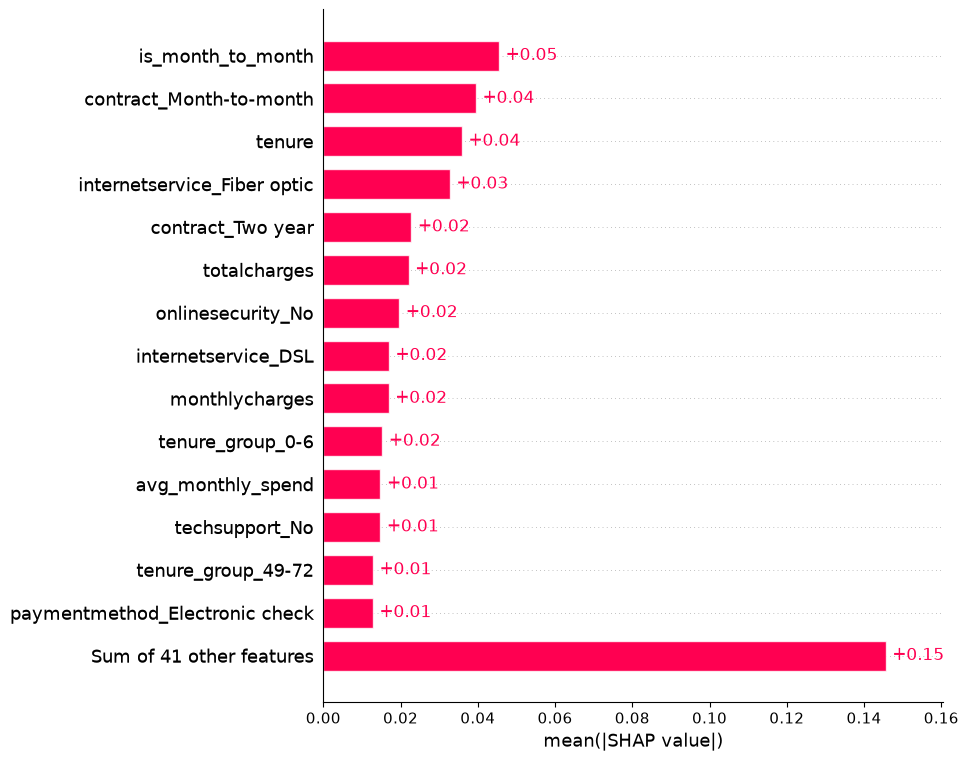

In [37]:
# Global Feature Importance
shap.plots.bar(
    shap_churn,
    max_display=15
)

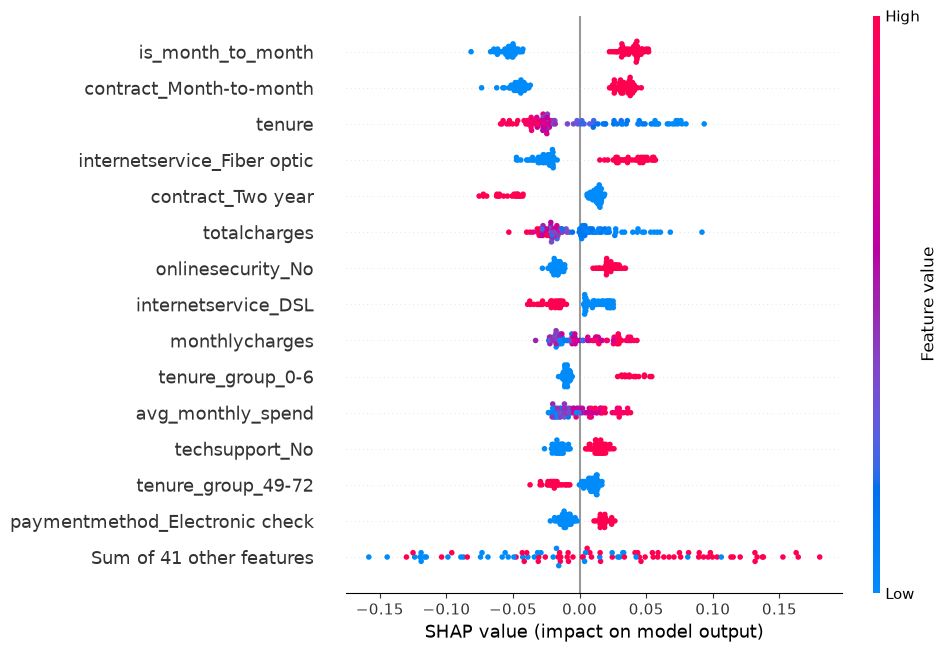

In [38]:
# SHAP Beeswarm Plot
shap.plots.beeswarm(
    shap_churn,
    max_display=15
)

In [39]:
# Explaining ONE custome
customer_index = 0

In [40]:
customer = X.iloc[
    [customer_index]
]

In [41]:
customer.T

,0
gender,Female
seniorcitizen,0
partner,Yes
dependents,No
tenure,1
phoneservice,No
multiplelines,No phone service
internetservice,DSL
onlinesecurity,No
onlinebackup,Yes


In [42]:
# Predicting customer's churn probability
customer_probability = model.predict_proba(
    customer
)[0, 1]

In [43]:
# Printing
print(
    "Churn Probability:",
    round(
        customer_probability * 100,
        2
    ),
    "%"
)

Churn Probability: 69.06 %


In [44]:
customer_prediction = int(
    customer_probability >= threshold
)

In [45]:
# Print
print(
    "Prediction:",
    "Churn"
    if customer_prediction == 1
    else "Stay"
)

Prediction: Churn


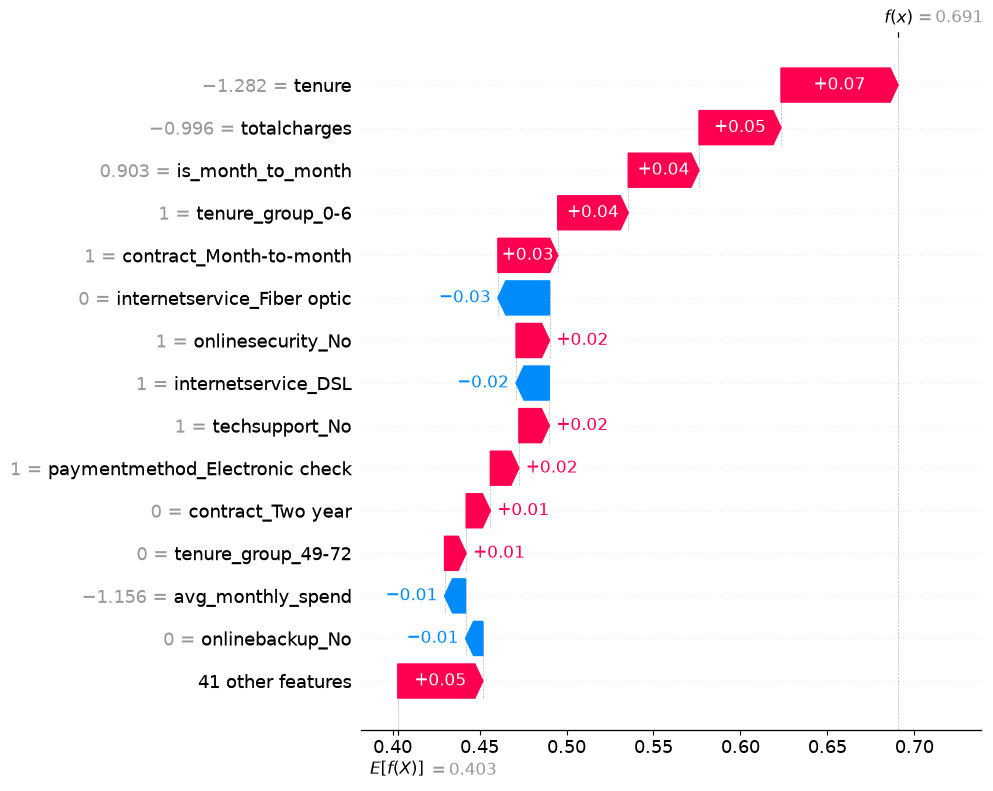

In [46]:
# SHAP Waterfall Plot
shap.plots.waterfall(
    shap_churn[
        customer_index
    ],
    max_display=15
)

In [47]:
# Extracting SHAP values into a table
customer_shap_values = (
    shap_churn[
        customer_index
    ].values
)

In [48]:
# Creating table
explanation_df = pd.DataFrame(
    {
        "feature": clean_feature_names,
        "shap_value": customer_shap_values
    }
)

In [49]:
# Add importance
explanation_df[
    "importance"
] = abs(
    explanation_df["shap_value"]
)

In [50]:
# Sorting
explanation_df = (
    explanation_df
    .sort_values(
        "importance",
        ascending=False
    )
)

In [51]:
explanation_df.head(15)

,feature,shap_value,importance
1,tenure,0.067343,0.067343
3,totalcharges,0.047149,0.047149
7,is_month_to_month,0.040681,0.040681
50,tenure_group_0-6,0.040547,0.040547
41,contract_Month-to-month,0.034414,0.034414
21,internetservice_Fiber optic,-0.029719,0.029719
23,onlinesecurity_No,0.019267,0.019267
20,internetservice_DSL,-0.019167,0.019167
32,techsupport_No,0.017534,0.017534
48,paymentmethod_Electronic check,0.016392,0.016392


In [52]:
# Separating risk-increasing and risk-reducing
risk_increasing = (
    explanation_df[
        explanation_df[
            "shap_value"
        ] > 0
    ]
    .head(5)
)

In [53]:
# Risk reducing
risk_reducing = (
    explanation_df[
        explanation_df[
            "shap_value"
        ] < 0
    ]
    .head(5)
)

In [54]:
risk_reducing = (
    explanation_df[
        explanation_df[
            "shap_value"
        ] < 0
    ]
    .sort_values(
        "shap_value"
    )
    .head(5)
)

In [55]:
risk_increasing

,feature,shap_value,importance
1,tenure,0.067343,0.067343
3,totalcharges,0.047149,0.047149
7,is_month_to_month,0.040681,0.040681
50,tenure_group_0-6,0.040547,0.040547
41,contract_Month-to-month,0.034414,0.034414


In [56]:
risk_reducing

,feature,shap_value,importance
21,internetservice_Fiber optic,-0.029719,0.029719
20,internetservice_DSL,-0.019167,0.019167
5,avg_monthly_spend,-0.012056,0.012056
26,onlinebackup_No,-0.009991,0.009991
28,onlinebackup_Yes,-0.007262,0.007262


In [57]:
# Printing a simple human-readable explanation
print(
    "TOP FACTORS INCREASING CHURN RISK"
)

for _, row in risk_increasing.iterrows():

    print(
        "↑",
        row["feature"],
        round(
            row["shap_value"],
            3
        )
    )

TOP FACTORS INCREASING CHURN RISK
↑ tenure 0.067
↑ totalcharges 0.047
↑ is_month_to_month 0.041
↑ tenure_group_0-6 0.041
↑ contract_Month-to-month 0.034


In [58]:
print(
    "\nTOP FACTORS REDUCING CHURN RISK"
)

for _, row in risk_reducing.iterrows():

    print(
        "↓",
        row["feature"],
        round(
            abs(row["shap_value"]),
            3
        )
    )


TOP FACTORS REDUCING CHURN RISK
↓ internetservice_Fiber optic 0.03
↓ internetservice_DSL 0.019
↓ avg_monthly_spend 0.012
↓ onlinebackup_No 0.01
↓ onlinebackup_Yes 0.007


In [59]:
# Building one reusable function
def explain_customer(
    customer_index,
    X,
    model,
    shap_values,
    feature_names,
    threshold
):

    customer = X.iloc[
        [customer_index]
    ]

    probability = model.predict_proba(
        customer
    )[0, 1]

    prediction = int(
        probability >= threshold
    )

    customer_values = shap_values[
        customer_index
    ].values

    explanation = pd.DataFrame(
        {
            "feature": feature_names,
            "shap_value": customer_values
        }
    )

    explanation[
        "importance"
    ] = abs(
        explanation["shap_value"]
    )

    explanation = explanation.sort_values(
        "importance",
        ascending=False
    )

    print(
        "Churn Probability:",
        round(
            probability * 100,
            2
        ),
        "%"
    )

    print(
        "Prediction:",
        "Churn"
        if prediction == 1
        else "Stay"
    )

    return explanation

In [60]:
explanation = explain_customer(
    0,
    X,
    model,
    shap_churn,
    clean_feature_names,
    threshold
)

Churn Probability: 69.06 %
Prediction: Churn


In [61]:
explanation.head(10)

,feature,shap_value,importance
1,tenure,0.067343,0.067343
3,totalcharges,0.047149,0.047149
7,is_month_to_month,0.040681,0.040681
50,tenure_group_0-6,0.040547,0.040547
41,contract_Month-to-month,0.034414,0.034414
21,internetservice_Fiber optic,-0.029719,0.029719
23,onlinesecurity_No,0.019267,0.019267
20,internetservice_DSL,-0.019167,0.019167
32,techsupport_No,0.017534,0.017534
48,paymentmethod_Electronic check,0.016392,0.016392


# Phase 8 : Generative AI Retention Assistant

In [62]:
customer_index = 0

customer_transformed_values = X_shap[
    customer_index
]

In [63]:
explanation["feature_value"] = (
    customer_transformed_values
)

In [64]:
# rearranging:
explanation = explanation[
    [
        "feature",
        "feature_value",
        "shap_value",
        "importance"
    ]
]

In [65]:
explanation.head(10)

,feature,feature_value,shap_value,importance
1,tenure,-0.441773,0.067343,0.067343
3,totalcharges,-1.281624,0.047149,0.047149
7,is_month_to_month,-1.164077,0.040681,0.040681
50,tenure_group_0-6,-0.995824,0.040547,0.040547
41,contract_Month-to-month,-0.933992,0.034414,0.034414
21,internetservice_Fiber optic,-1.156095,-0.029719,0.029719
23,onlinesecurity_No,-0.879415,0.019267,0.019267
20,internetservice_DSL,0.903464,-0.019167,0.019167
32,techsupport_No,-0.643274,0.017534,0.017534
48,paymentmethod_Electronic check,1.000000,0.016392,0.016392


In [66]:
# Extracting strongest risk factors
risk_factors = (
    explanation[
        explanation["shap_value"] > 0
    ]
    .sort_values(
        "shap_value",
        ascending=False
    )
    .head(5)
)

In [67]:
risk_factors

,feature,feature_value,shap_value,importance
1,tenure,-0.441773,0.067343,0.067343
3,totalcharges,-1.281624,0.047149,0.047149
7,is_month_to_month,-1.164077,0.040681,0.040681
50,tenure_group_0-6,-0.995824,0.040547,0.040547
41,contract_Month-to-month,-0.933992,0.034414,0.034414


In [68]:
# Factors reducing churn risk
protective_factors = (
    explanation[
        explanation["shap_value"] < 0
    ]
    .sort_values(
        "shap_value"
    )
    .head(5)
)

In [69]:
protective_factors

,feature,feature_value,shap_value,importance
21,internetservice_Fiber optic,-1.156095,-0.029719,0.029719
20,internetservice_DSL,0.903464,-0.019167,0.019167
5,avg_monthly_spend,1.000000,-0.012056,0.012056
26,onlinebackup_No,1.000000,-0.009991,0.009991
28,onlinebackup_Yes,0.000000,-0.007262,0.007262


In [70]:
# Printing them clearly
print("FACTORS INCREASING CHURN RISK")
print("--------------------------------")

for _, row in risk_factors.iterrows():
    print(
        row["feature"],
        "| SHAP:",
        round(row["shap_value"], 3)
    )

FACTORS INCREASING CHURN RISK
--------------------------------
tenure | SHAP: 0.067
totalcharges | SHAP: 0.047
is_month_to_month | SHAP: 0.041
tenure_group_0-6 | SHAP: 0.041
contract_Month-to-month | SHAP: 0.034


In [71]:
print("\nFACTORS REDUCING CHURN RISK")
print("--------------------------------")

for _, row in protective_factors.iterrows():
    print(
        row["feature"],
        "| SHAP:",
        round(row["shap_value"], 3)
    )


FACTORS REDUCING CHURN RISK
--------------------------------
internetservice_Fiber optic | SHAP: -0.03
internetservice_DSL | SHAP: -0.019
avg_monthly_spend | SHAP: -0.012
onlinebackup_No | SHAP: -0.01
onlinebackup_Yes | SHAP: -0.007


In [72]:
# Getting the original customer's information
customer_index = 0

In [73]:
# Get Original customer
customer_data = X.iloc[
    customer_index
]

In [74]:
customer_data

gender                         Female
seniorcitizen                       0
partner                           Yes
dependents                         No
tenure                              1
phoneservice                       No
multiplelines        No phone service
internetservice                   DSL
onlinesecurity                     No
onlinebackup                      Yes
deviceprotection                   No
techsupport                        No
streamingtv                        No
streamingmovies                    No
contract               Month-to-month
paperlessbilling                  Yes
paymentmethod        Electronic check
monthlycharges                  29.85
totalcharges                    29.85
tenure_group                      0-6
total_services                      2
avg_monthly_spend               29.85
automatic_payment                   0
is_month_to_month                   1
has_tech_support                    0
Name: 0, dtype: object

In [75]:
# Calculating prediction again
customer = X.iloc[
    [customer_index]
]

In [76]:
# Get probability:
probability = model.predict_proba(
    customer
)[0, 1]

In [77]:
prediction = int(
    probability >= threshold
)

In [78]:
print(
    "Probability:",
    round(probability * 100, 2),
    "%"
)

print(
    "Prediction:",
    "Churn"
    if prediction == 1
    else "Stay"
)

Probability: 69.06 %
Prediction: Churn


In [79]:
# Creating a risk category
def get_risk_category(probability):

    if probability >= 0.80:
        return "Critical"

    elif probability >= 0.60:
        return "High"

    elif probability >= 0.40:
        return "Medium"

    else:
        return "Low"

In [80]:
risk_category = get_risk_category(
    probability
)

In [81]:
print(
    "Risk Category:",
    risk_category
)

Risk Category: High


**Adding Gemini**

In [82]:
# Installing libraries
!pip install -U google-genai python-dotenv

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.2 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.2 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.2 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.2 MB ? eta -:--:--
   -------- ----------------------


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [84]:
# Loading environment variables
import os

from dotenv import load_dotenv
from google import genai

In [85]:
load_dotenv(
    "../.env"
)

True

In [86]:
api_key = os.getenv(
    "GEMINI_API_KEY"
)

print(
    "API key loaded:",
    api_key is not None
)

API key loaded: True


In [87]:
# Creating Gemini client
client = genai.Client(
    api_key=api_key
)

In [88]:
# Testing Gemini first
import time
from google.genai.errors import ServerError

for attempt in range(5):
    try:
        response = client.models.generate_content(
            model="gemini-3.8-flash",
            contents="Explain customer churn in one sentence."
        )

        print(response.text)
        break

    except ServerError as e:
        print(f"Attempt {attempt + 1} failed. Retrying...")

        time.sleep(3)

else:
    print("Gemini is still unavailable. Try again after some time.")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Attempt 1 failed. Retrying...
Customer churn is the rate at which customers stop doing business with a company or cancel their subscriptions over a specific period.


In [89]:
print(
    response.text
)

Customer churn is the rate at which customers stop doing business with a company or cancel their subscriptions over a specific period.


In [90]:
# Converting SHAP factors into text
risk_factor_text = ""

In [91]:
# 1. Choose customer
customer_index = 0

In [92]:
# 2. Get SHAP values for that customer
customer_shap_values = shap_churn[
    customer_index
].values

In [93]:
# 3. Create explanation dataframe
explanation = pd.DataFrame(
    {
        "feature": clean_feature_names,
        "shap_value": customer_shap_values
    }
)

In [94]:
# 4. Add importance
explanation["importance"] = abs(
    explanation["shap_value"]
)

In [95]:
# 5. Sort important features
explanation = explanation.sort_values(
    "importance",
    ascending=False
)

In [96]:
explanation.head(10)

,feature,shap_value,importance
1,tenure,0.067343,0.067343
3,totalcharges,0.047149,0.047149
7,is_month_to_month,0.040681,0.040681
50,tenure_group_0-6,0.040547,0.040547
41,contract_Month-to-month,0.034414,0.034414
21,internetservice_Fiber optic,-0.029719,0.029719
23,onlinesecurity_No,0.019267,0.019267
20,internetservice_DSL,-0.019167,0.019167
32,techsupport_No,0.017534,0.017534
48,paymentmethod_Electronic check,0.016392,0.016392


In [97]:
for _, row in risk_factors.iterrows():

    risk_factor_text += (
        f"- {row['feature']} "
        f"(SHAP impact: "
        f"{row['shap_value']:.3f})\n"
    )

In [98]:
print(
    risk_factor_text
)

- tenure (SHAP impact: 0.067)
- totalcharges (SHAP impact: 0.047)
- is_month_to_month (SHAP impact: 0.041)
- tenure_group_0-6 (SHAP impact: 0.041)
- contract_Month-to-month (SHAP impact: 0.034)



In [99]:
# Adding protective factors
protective_factor_text = ""

In [100]:
for _, row in protective_factors.iterrows():

    protective_factor_text += (
        f"- {row['feature']} "
        f"(SHAP impact: "
        f"{row['shap_value']:.3f})\n"
    )

In [101]:
# Adding useful original customer information
customer_summary = f"""
Tenure: {customer_data['tenure']} months
Contract: {customer_data['contract']}
Internet Service: {customer_data['internetservice']}
Monthly Charges: {customer_data['monthlycharges']}
Total Charges: {customer_data['totalcharges']}
Tech Support: {customer_data['techsupport']}
Online Security: {customer_data['onlinesecurity']}
Payment Method: {customer_data['paymentmethod']}
Paperless Billing: {customer_data['paperlessbilling']}
"""

In [102]:
print(
    customer_summary
)


Tenure: 1 months
Contract: Month-to-month
Internet Service: DSL
Monthly Charges: 29.85
Total Charges: 29.85
Tech Support: No
Online Security: No
Payment Method: Electronic check
Paperless Billing: Yes



In [103]:
# Building a strong AI prompt
prompt = f"""
You are a customer-retention assistant for a telecom company.

A machine-learning churn model has already analyzed this customer.

IMPORTANT RULES:
1. Do not calculate or change the churn probability.
2. Do not claim that a factor causes churn.
3. Treat SHAP values as explanations of model behavior.
4. Use only the information provided below.
5. Do not invent customer information.
6. Recommendations should be practical and specific.
7. Prefer actionable service, billing, contract, or support changes.
8. Do not base retention offers on gender, age, or other demographic characteristics.

MODEL RESULT

Churn Probability:
{probability * 100:.2f}%

Risk Category:
{risk_category}

Prediction:
{"Churn" if prediction == 1 else "Stay"}

CUSTOMER INFORMATION

{customer_summary}

FACTORS INCREASING THE MODEL'S CHURN PREDICTION

{risk_factor_text}

FACTORS REDUCING THE MODEL'S CHURN PREDICTION

{protective_factor_text}

Generate the following:

1. Customer Risk Summary
   Explain the prediction in 2-3 simple sentences.

2. Main Risk Factors
   Explain the most important factors in easy language.

3. Recommended Retention Actions
   Give exactly 3 practical actions.

4. Priority
   State whether intervention priority is Low, Medium, High,
   or Critical.

Keep the answer concise and suitable for a customer-retention manager.
"""

In [104]:
# Checking prompt
print(
    prompt
)


You are a customer-retention assistant for a telecom company.

A machine-learning churn model has already analyzed this customer.

IMPORTANT RULES:
1. Do not calculate or change the churn probability.
2. Do not claim that a factor causes churn.
3. Treat SHAP values as explanations of model behavior.
4. Use only the information provided below.
5. Do not invent customer information.
6. Recommendations should be practical and specific.
7. Prefer actionable service, billing, contract, or support changes.
8. Do not base retention offers on gender, age, or other demographic characteristics.

MODEL RESULT

Churn Probability:
69.06%

Risk Category:
High

Prediction:
Churn

CUSTOMER INFORMATION


Tenure: 1 months
Contract: Month-to-month
Internet Service: DSL
Monthly Charges: 29.85
Total Charges: 29.85
Tech Support: No
Online Security: No
Payment Method: Electronic check
Paperless Billing: Yes


FACTORS INCREASING THE MODEL'S CHURN PREDICTION

- tenure (SHAP impact: 0.067)
- totalcharges (SHAP

In [105]:
# Sending it to Gemini
response = client.models.generate_content(
    model="gemini-3.8-flash",
    contents=prompt
)

In [106]:
ai_recommendation = response.text

In [107]:
print(
    ai_recommendation
)

### 1. Customer Risk Summary
The model predicts this customer will churn, with an estimated churn probability of 69.06%, placing them in the High risk category. This prediction is primarily driven by the customer being in their first month of service and holding a month-to-month contract. 

### 2. Main Risk Factors
* **Short Tenure and Low Total Charges:** The customer has only been with the company for 1 month (falling in the 0–6 month tenure group with $29.85 in total charges), which the model heavily associates with higher churn likelihood.
* **Month-to-Month Contract Status:** Having a flexible, month-to-month agreement rather than a multi-year commitment strongly pushed the model's prediction toward churn.

### 3. Recommended Retention Actions
1. **Contract Upgrade Incentive:** Offer a promotional discount or bill credit to encourage the customer to switch from a month-to-month contract to a 1-year agreement.
2. **Onboarding Support & Add-on Trial:** Provide a free trial or onboar

In [108]:
# Turning everything into one reusable function
def generate_retention_advice(
    probability,
    prediction,
    risk_category,
    customer_data,
    risk_factors,
    protective_factors
):

    risk_text = ""

    for _, row in risk_factors.iterrows():

        risk_text += (
            f"- {row['feature']} "
            f"(SHAP impact: "
            f"{row['shap_value']:.3f})\n"
        )


    protective_text = ""

    for _, row in protective_factors.iterrows():

        protective_text += (
            f"- {row['feature']} "
            f"(SHAP impact: "
            f"{row['shap_value']:.3f})\n"
        )


    customer_summary = f"""
Tenure: {customer_data['tenure']} months
Contract: {customer_data['contract']}
Internet Service: {customer_data['internetservice']}
Monthly Charges: {customer_data['monthlycharges']}
Total Charges: {customer_data['totalcharges']}
Tech Support: {customer_data['techsupport']}
Online Security: {customer_data['onlinesecurity']}
Payment Method: {customer_data['paymentmethod']}
Paperless Billing: {customer_data['paperlessbilling']}
"""


    prompt = f"""
You are a customer-retention assistant.

The machine-learning model has already performed the prediction.

Do not recalculate the probability.
Do not invent customer facts.
Do not describe correlations as proven causes.
Do not recommend actions based on demographic characteristics.

Churn Probability:
{probability * 100:.2f}%

Prediction:
{"Churn" if prediction == 1 else "Stay"}

Risk Category:
{risk_category}

Customer Information:
{customer_summary}

Factors increasing model churn prediction:
{risk_text}

Factors reducing model churn prediction:
{protective_text}

Provide:

1. Customer Risk Summary
2. Main Risk Factors
3. Exactly 3 Retention Actions
4. Intervention Priority

Keep the response concise and practical.
"""


    response = client.models.generate_content(
        model="gemini-3.8-flash",
        contents=prompt
    )

    return response.text

In [109]:
# Testing the function
ai_advice = generate_retention_advice(
    probability,
    prediction,
    risk_category,
    customer_data,
    risk_factors,
    protective_factors
)

In [110]:
print(
    ai_advice
)

### 1. Customer Risk Summary
The customer is in the **High Risk** category with a model-predicted churn probability of **69.06%**. They are a brand-new customer (1-month tenure) on a month-to-month DSL service plan ($29.85/month) without supplementary services like Tech Support or Online Security.

---

### 2. Main Risk Factors
*(Factors associated with the model's higher churn prediction)*
* **Very Low Tenure:** Being in the first month of service (tenure group 0–6) contributes most strongly to the elevated risk score.
* **Contract Structure:** A month-to-month agreement allows immediate cancellation without commitment barriers.
* **Low Cumulative Spend / Early Lifecycle:** Minimal historical interaction and low total charges to date align with higher churn likelihood in the model.

---

### 3. Exactly 3 Retention Actions
1. **Contract Transition Offer:** Present an introductory incentive (such as a bill credit or fixed promotional rate) to migrate from a month-to-month plan to an ann

In [112]:
# Adding a fallback to prevent crashing
try:

    response = client.models.generate_content(
        model="gemini-3.8-flash",
        contents=prompt
    )

    ai_recommendation = response.text

except Exception as e:

    ai_recommendation = (
        "AI recommendation is temporarily unavailable. "
        "The ML churn prediction is still available."
    )

In [114]:
print(ai_recommendation)

AI recommendation is temporarily unavailable. The ML churn prediction is still available.


In [115]:
print(
    "Churn Probability:",
    round(probability * 100, 2),
    "%"
)

print(
    "Prediction:",
    "Churn" if prediction == 1 else "Stay"
)

print(
    "Risk Category:",
    risk_category
)

print(
    "\nAI Recommendation:"
)

print(ai_recommendation)

Churn Probability: 69.06 %
Prediction: Churn
Risk Category: High

AI Recommendation:
AI recommendation is temporarily unavailable. The ML churn prediction is still available.
